In [1]:
pip install pandas numpy requests matplotlib scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
!pip install pandas numpy matplotlib scikit-learn statsmodels requests


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import sklearn
import statsmodels

print("All packages imported successfully")

All packages imported successfully


In [111]:


# ---------------------------
# 1) OpenAQ test: Delhi PM2.5 locations
# ---------------------------
openaq_url = "https://api.openaq.org/v3/locations"
openaq_params = {
    "country_id": 91,
    "city": "Delhi",
    "parameters_id": 2,
    "limit": 5
}

openaq_resp = requests.get(openaq_url, params=openaq_params, timeout=30)
print("OpenAQ status:", openaq_resp.status_code)

if openaq_resp.status_code == 200:
    openaq_json = openaq_resp.json()
    print("OpenAQ keys:", openaq_json.keys())
    print("OpenAQ sample result count:", len(openaq_json.get("results", [])))
    if openaq_json.get("results"):
        print("First OpenAQ record:")
        print(openaq_json["results"][0])
else:
    print(openaq_resp.text)

# ---------------------------
# 2) NASA POWER test: Delhi daily weather
# ---------------------------
nasa_url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point"
    "?parameters=T2M,RH2M,WS10M,PRECTOTCORR"
    "&community=RE"
    "&longitude=77.2090"
    "&latitude=28.6139"
    "&start=20240101"
    "&end=20240110"
    "&format=JSON"
)

nasa_resp = requests.get(nasa_url, timeout=30)
print("\nNASA POWER status:", nasa_resp.status_code)

if nasa_resp.status_code == 200:
    nasa_json = nasa_resp.json()
    print("NASA keys:", nasa_json.keys())
    print("NASA parameter keys:",
          nasa_json["properties"]["parameter"].keys())
    print("NASA sample T2M values:",
          list(nasa_json["properties"]["parameter"]["T2M"].items())[:3])
else:
    print(nasa_resp.text)

OpenAQ status: 401
{"message": "Unauthorized. A valid API key must be provided in the X-API-Key header."}

NASA POWER status: 200
NASA keys: dict_keys(['type', 'geometry', 'properties', 'header', 'messages', 'parameters', 'times'])
NASA parameter keys: dict_keys(['T2M', 'RH2M', 'WS10M', 'PRECTOTCORR'])
NASA sample T2M values: [('20240101', 12.19), ('20240102', 12.34), ('20240103', 13.09)]


In [113]:


air_url = (
    "https://air-quality-api.open-meteo.com/v1/air-quality"
    "?latitude=28.6139"
    "&longitude=77.2090"
    "&hourly=pm2_5,pm10,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi"
    "&timezone=auto"
    "&past_days=7"
)

resp = requests.get(air_url, timeout=30)
print("Open-Meteo Air Quality status:", resp.status_code)

if resp.status_code == 200:
    data = resp.json()
    print(data.keys())
    print(data["hourly"].keys())
    print("First 3 times:", data["hourly"]["time"][:3])
    print("First 3 PM2.5 values:", data["hourly"]["pm2_5"][:3])
else:
    print(resp.text)

Open-Meteo Air Quality status: 200
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])
dict_keys(['time', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'us_aqi'])
First 3 times: ['2026-03-22T00:00', '2026-03-22T01:00', '2026-03-22T02:00']
First 3 PM2.5 values: [90.6, 83.4, 76.4]


In [115]:

print(os.getcwd())

C:\Users\swapn\OneDrive\Desktop\Delhi Air Quality Project


In [119]:

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

print("Folders created")

Folders created


In [29]:
air_df.to_csv("data/raw/delhi_air_quality_hourly_2025.csv", index=False)
print("File saved successfully")

File saved successfully


In [121]:


os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

print("Folders ready")
print(os.path.exists("data/raw"))
print(os.path.exists("data/processed"))

Folders ready
True
True


In [42]:
air_df.to_csv("data/raw/delhi_air_quality_hourly_2025.csv", index=False)
print("saved")
print(air_df.shape)

saved
(8760, 7)


In [123]:

nasa_url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point"
    "?parameters=T2M,RH2M,WS10M,PRECTOTCORR"
    "&community=RE"
    "&longitude=77.2090"
    "&latitude=28.6139"
    "&start=20250101"
    "&end=20251231"
    "&format=JSON"
)

resp = requests.get(nasa_url, timeout=60)
print("Status:", resp.status_code)

data = resp.json()

weather_df = pd.DataFrame({
    "date": list(data["properties"]["parameter"]["T2M"].keys()),
    "T2M": list(data["properties"]["parameter"]["T2M"].values()),
    "RH2M": list(data["properties"]["parameter"]["RH2M"].values()),
    "WS10M": list(data["properties"]["parameter"]["WS10M"].values()),
    "PRECTOTCORR": list(data["properties"]["parameter"]["PRECTOTCORR"].values())
})

weather_df["date"] = pd.to_datetime(weather_df["date"], format="%Y%m%d")

print(weather_df.head())
print(weather_df.shape)

Status: 200
        date    T2M   RH2M  WS10M  PRECTOTCORR
0 2025-01-01  12.22  45.72   3.66          0.0
1 2025-01-02  13.24  47.31   3.77          0.0
2 2025-01-03  14.55  51.30   2.65          0.0
3 2025-01-04  15.22  51.49   2.24          0.0
4 2025-01-05  14.42  56.55   2.83          0.0
(365, 5)


In [46]:
weather_df.to_csv("data/raw/delhi_weather_daily_2025.csv", index=False)
print("saved")
print(weather_df.shape)

saved
(365, 5)


In [48]:
air_daily = air_df.copy()

air_daily["date"] = air_daily["datetime"].dt.date
air_daily["date"] = pd.to_datetime(air_daily["date"])

air_daily = air_daily.groupby("date", as_index=False).agg({
    "pm2_5": "mean",
    "pm10": "mean",
    "nitrogen_dioxide": "mean",
    "sulphur_dioxide": "mean",
    "ozone": "mean",
    "us_aqi": "mean"
})

print(air_daily.head())
print(air_daily.shape)

        date       pm2_5        pm10  nitrogen_dioxide  sulphur_dioxide  \
0 2025-01-01  145.175000  147.837500         34.616667        31.283333   
1 2025-01-02  145.370833  149.341667         33.241667        38.100000   
2 2025-01-03  158.791667  168.179167         54.083333        48.366667   
3 2025-01-04  166.491667  176.479167         76.295833        63.462500   
4 2025-01-05  158.225000  163.804167         44.412500        48.441667   

       ozone      us_aqi  
0  77.375000  200.000000  
1  81.291667  196.541667  
2  62.875000  201.875000  
3  77.208333  213.833333  
4  94.333333  217.583333  
(365, 7)


In [50]:
merged_df = air_daily.merge(weather_df, on="date", how="inner")

print(merged_df.head())
print(merged_df.shape)
print(merged_df.isna().sum())

        date       pm2_5        pm10  nitrogen_dioxide  sulphur_dioxide  \
0 2025-01-01  145.175000  147.837500         34.616667        31.283333   
1 2025-01-02  145.370833  149.341667         33.241667        38.100000   
2 2025-01-03  158.791667  168.179167         54.083333        48.366667   
3 2025-01-04  166.491667  176.479167         76.295833        63.462500   
4 2025-01-05  158.225000  163.804167         44.412500        48.441667   

       ozone      us_aqi    T2M   RH2M  WS10M  PRECTOTCORR  
0  77.375000  200.000000  12.22  45.72   3.66          0.0  
1  81.291667  196.541667  13.24  47.31   3.77          0.0  
2  62.875000  201.875000  14.55  51.30   2.65          0.0  
3  77.208333  213.833333  15.22  51.49   2.24          0.0  
4  94.333333  217.583333  14.42  56.55   2.83          0.0  
(365, 11)
date                0
pm2_5               0
pm10                0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
us_aqi              0
T2M                

In [52]:
model_df = merged_df.copy()

model_df["target_pm2_5_next_day"] = model_df["pm2_5"].shift(-1)

model_df = model_df.dropna().reset_index(drop=True)

print(model_df[["date", "pm2_5", "target_pm2_5_next_day"]].head())
print(model_df.shape)

        date       pm2_5  target_pm2_5_next_day
0 2025-01-01  145.175000             145.370833
1 2025-01-02  145.370833             158.791667
2 2025-01-03  158.791667             166.491667
3 2025-01-04  166.491667             158.225000
4 2025-01-05  158.225000             141.204167
(364, 12)


In [54]:
model_df.to_csv("data/processed/delhi_pm25_model_data_2025.csv", index=False)
print("saved")
print(model_df.shape)

saved
(364, 12)


In [56]:
print(model_df.columns)
print(model_df.dtypes)
print(model_df.describe())

Index(['date', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
       'us_aqi', 'T2M', 'RH2M', 'WS10M', 'PRECTOTCORR',
       'target_pm2_5_next_day'],
      dtype='object')
date                     datetime64[ns]
pm2_5                           float64
pm10                            float64
nitrogen_dioxide                float64
sulphur_dioxide                 float64
ozone                           float64
us_aqi                          float64
T2M                             float64
RH2M                            float64
WS10M                           float64
PRECTOTCORR                     float64
target_pm2_5_next_day           float64
dtype: object
                      date       pm2_5        pm10  nitrogen_dioxide  \
count                  364  364.000000  364.000000        364.000000   
mean   2025-07-01 12:00:00   80.047379  199.229453         33.775893   
min    2025-01-01 00:00:00   17.483333   17.645833         10.179167   
25%    2025-04-01 18:00:00 

In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


baseline_df = model_df.copy()

baseline_df["baseline_pred"] = baseline_df["pm2_5"]

y_true = baseline_df["target_pm2_5_next_day"]
y_pred = baseline_df["baseline_pred"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("Baseline MAE:", mae)
print("Baseline RMSE:", rmse)
print("Baseline R2:", r2)

Baseline MAE: 15.52478250915751
Baseline RMSE: 22.963507026633046
Baseline R2: 0.6284562026479149


In [127]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


feature_cols = [
    "pm2_5",
    "pm10",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "us_aqi",
    "T2M",
    "RH2M",
    "WS10M",
    "PRECTOTCORR"
]

X = model_df[feature_cols]
y = model_df["target_pm2_5_next_day"]

# time-based split
split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", mae)
print("Random Forest RMSE:", rmse)
print("Random Forest R2:", r2)

Random Forest MAE: 25.21664626997164
Random Forest RMSE: 33.297389017724925
Random Forest R2: 0.43139836850800795


In [129]:
from sklearn.linear_model import LinearRegression


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE:", mae)
print("Linear Regression RMSE:", rmse)
print("Linear Regression R2:", r2)

Linear Regression MAE: 22.135159899716047
Linear Regression RMSE: 28.68495935551867
Linear Regression R2: 0.5780157720924226


In [64]:
feature_df = merged_df.copy()

feature_df["pm2_5_lag1"] = feature_df["pm2_5"].shift(1)
feature_df["pm2_5_lag2"] = feature_df["pm2_5"].shift(2)
feature_df["pm2_5_lag3"] = feature_df["pm2_5"].shift(3)
feature_df["pm2_5_roll3"] = feature_df["pm2_5"].rolling(window=3).mean()

feature_df["target_pm2_5_next_day"] = feature_df["pm2_5"].shift(-1)

feature_df = feature_df.dropna().reset_index(drop=True)

print(feature_df[[
    "date", "pm2_5", "pm2_5_lag1", "pm2_5_lag2", "pm2_5_lag3",
    "pm2_5_roll3", "target_pm2_5_next_day"
]].head())

print(feature_df.shape)

        date       pm2_5  pm2_5_lag1  pm2_5_lag2  pm2_5_lag3  pm2_5_roll3  \
0 2025-01-04  166.491667  158.791667  145.370833  145.175000   156.884722   
1 2025-01-05  158.225000  166.491667  158.791667  145.370833   161.169444   
2 2025-01-06  141.204167  158.225000  166.491667  158.791667   155.306944   
3 2025-01-07  109.766667  141.204167  158.225000  166.491667   136.398611   
4 2025-01-08   71.920833  109.766667  141.204167  158.225000   107.630556   

   target_pm2_5_next_day  
0             158.225000  
1             141.204167  
2             109.766667  
3              71.920833  
4             161.037500  
(361, 16)


In [131]:


feature_cols_lag = [
    "pm2_5",
    "pm10",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "us_aqi",
    "T2M",
    "RH2M",
    "WS10M",
    "PRECTOTCORR",
    "pm2_5_lag1",
    "pm2_5_lag2",
    "pm2_5_lag3",
    "pm2_5_roll3"
]

X = feature_df[feature_cols_lag]
y = feature_df["target_pm2_5_next_day"]

split_idx = int(len(feature_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

lr_model_lag = LinearRegression()
lr_model_lag.fit(X_train, y_train)
lr_pred_lag = lr_model_lag.predict(X_test)

mae = mean_absolute_error(y_test, lr_pred_lag)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred_lag))
r2 = r2_score(y_test, lr_pred_lag)

print("Lag Linear Regression MAE:", mae)
print("Lag Linear Regression RMSE:", rmse)
print("Lag Linear Regression R2:", r2)

Lag Linear Regression MAE: 21.346220069798147
Lag Linear Regression RMSE: 28.411180842858215
Lag Linear Regression R2: 0.5860324392263299


In [135]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

small_features = [
    "pm2_5",
    "pm2_5_lag1",
    "pm2_5_lag2",
    "pm2_5_lag3",
    "pm2_5_roll3"
]

X = feature_df[small_features]
y = feature_df["target_pm2_5_next_day"]

split_idx = int(len(feature_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

small_lr = LinearRegression()
small_lr.fit(X_train, y_train)
small_pred = small_lr.predict(X_test)

mae = mean_absolute_error(y_test, small_pred)
rmse = np.sqrt(mean_squared_error(y_test, small_pred))
r2 = r2_score(y_test, small_pred)

print("Small Linear Regression MAE:", mae)
print("Small Linear Regression RMSE:", rmse)
print("Small Linear Regression R2:", r2)

Small Linear Regression MAE: 21.35746009576916
Small Linear Regression RMSE: 28.748038734292866
Small Linear Regression R2: 0.5761578109081182


In [70]:
feature_df["month"] = feature_df["date"].dt.month

season_features = [
    "pm2_5",
    "pm2_5_lag1",
    "pm2_5_lag2",
    "pm2_5_lag3",
    "pm2_5_roll3",
    "month"
]

X = feature_df[season_features]
y = feature_df["target_pm2_5_next_day"]

split_idx = int(len(feature_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

season_lr = LinearRegression()
season_lr.fit(X_train, y_train)
season_pred = season_lr.predict(X_test)

mae = mean_absolute_error(y_test, season_pred)
rmse = np.sqrt(mean_squared_error(y_test, season_pred))
r2 = r2_score(y_test, season_pred)

print("Season Linear Regression MAE:", mae)
print("Season Linear Regression RMSE:", rmse)
print("Season Linear Regression R2:", r2)

Season Linear Regression MAE: 24.39105141993273
Season Linear Regression RMSE: 32.5467789276227
Season Linear Regression R2: 0.4567449534663567


In [133]:
from sklearn.ensemble import RandomForestRegressor


rf_features = [
    "pm2_5",
    "pm2_5_lag1",
    "pm2_5_lag2",
    "pm2_5_lag3",
    "pm2_5_roll3"
]

X = feature_df[rf_features]
y = feature_df["target_pm2_5_next_day"]

split_idx = int(len(feature_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

rf_small = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf_small.fit(X_train, y_train)
rf_small_pred = rf_small.predict(X_test)

mae = mean_absolute_error(y_test, rf_small_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_small_pred))
r2 = r2_score(y_test, rf_small_pred)

print("Small Random Forest MAE:", mae)
print("Small Random Forest RMSE:", rmse)
print("Small Random Forest R2:", r2)

Small Random Forest MAE: 24.293735204551393
Small Random Forest RMSE: 33.489387293083716
Small Random Forest R2: 0.4248221603695358


In [74]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest (all features)",
        "Linear Regression (all features)",
        "Linear Regression (lag features)",
        "Linear Regression (PM2.5 time features only)",
        "Linear Regression (time features + month)",
        "Random Forest (PM2.5 time features only)"
    ],
    "MAE": [
        15.52478250915751,
        25.2164626997164,
        22.135159899716047,
        21.346220069798147,
        21.3574609576916,
        24.39105141993273,
        24.293735204551393
    ],
    "RMSE": [
        22.963507026633046,
        33.297389017724925,
        28.68495935551867,
        28.411180842858215,
        28.748038734292866,
        32.5467789276227,
        33.489387293083716
    ],
    "R2": [
        0.6284562026479149,
        0.4319836850800795,
        0.5780157720924226,
        0.5860324392263299,
        0.5761578109081182,
        0.4567449534663567,
        0.4248221603695358
    ]
})

print(results_df.sort_values(by="RMSE"))

                                          Model        MAE       RMSE  \
0                                      Baseline  15.524783  22.963507   
3              Linear Regression (lag features)  21.346220  28.411181   
2              Linear Regression (all features)  22.135160  28.684959   
4  Linear Regression (PM2.5 time features only)  21.357461  28.748039   
5     Linear Regression (time features + month)  24.391051  32.546779   
1                  Random Forest (all features)  25.216463  33.297389   
6      Random Forest (PM2.5 time features only)  24.293735  33.489387   

         R2  
0  0.628456  
3  0.586032  
2  0.578016  
4  0.576158  
5  0.456745  
1  0.431984  
6  0.424822  


In [76]:
results_df.to_csv("outputs/model_comparison_2025.csv", index=False)
print("saved")

saved


## Modeling conclusion

The baseline persistence model, which predicts next-day PM2.5 as equal to current-day PM2.5, outperformed all tested machine learning models on the 2025 Delhi dataset.

This suggests that short-term PM2.5 persistence is a very strong signal in the data, and that the additional models tested here did not yet capture enough extra predictive structure to beat that simple benchmark.

Among the trained models, Linear Regression with lag features performed best after the baseline, while Random Forest models performed substantially worse.

This is an important forecasting result because in time-series problems, complex models do not automatically outperform a strong naive baseline.

In [83]:
def pm25_risk_category(x):
    if x <= 30:
        return "Low"
    elif x <= 60:
        return "Moderate"
    elif x <= 90:
        return "High"
    else:
        return "Very High"

model_df["risk_category_next_day"] = model_df["target_pm2_5_next_day"].apply(pm25_risk_category)

print(model_df[["target_pm2_5_next_day", "risk_category_next_day"]].head())
print(model_df["risk_category_next_day"].value_counts())

   target_pm2_5_next_day risk_category_next_day
0             145.370833              Very High
1             158.791667              Very High
2             166.491667              Very High
3             158.225000              Very High
4             141.204167              Very High
risk_category_next_day
High         133
Moderate     114
Very High    110
Low            7
Name: count, dtype: int64


In [85]:
model_df.to_csv("data/processed/delhi_pm25_model_data_with_risk_2025.csv", index=False)
print("saved")

saved


In [87]:
risk_summary = model_df.groupby("risk_category_next_day")["target_pm2_5_next_day"].agg(["count", "mean", "min", "max"]).reset_index()

print(risk_summary)

  risk_category_next_day  count        mean        min         max
0                   High    133   73.856046  60.133333   89.625000
1                    Low      7   23.170833  17.483333   29.179167
2               Moderate    114   48.155958  30.054167   59.770833
3              Very High    110  124.423220  90.233333  256.733333


In [89]:
risk_summary.to_csv("outputs/risk_summary_2025.csv", index=False)
print("saved")

saved


In [91]:
risk_summary.to_csv("outputs/risk_summary_2025.csv", index=False)
print("saved")

saved


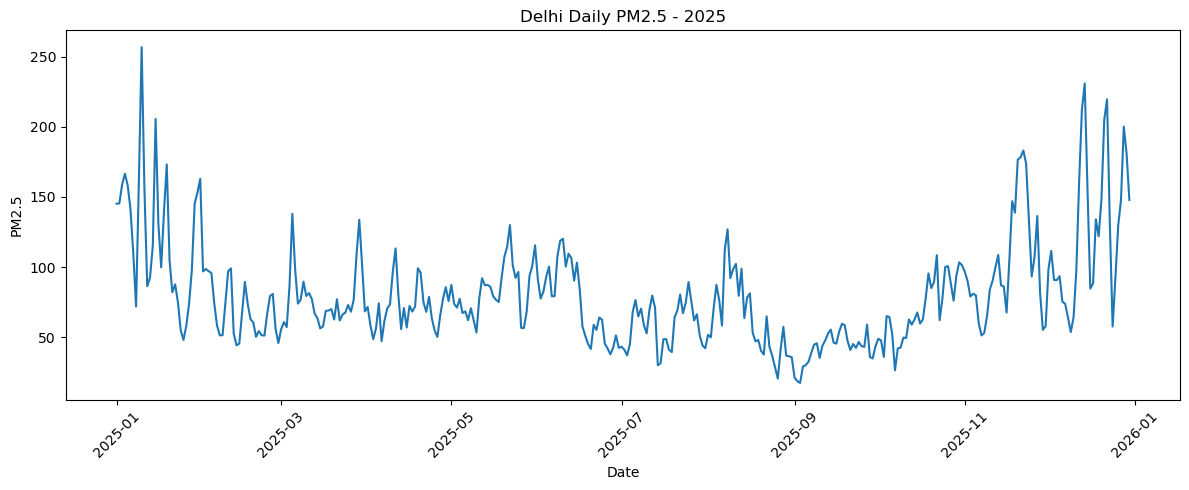

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(model_df["date"], model_df["pm2_5"])
plt.title("Delhi Daily PM2.5 - 2025")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

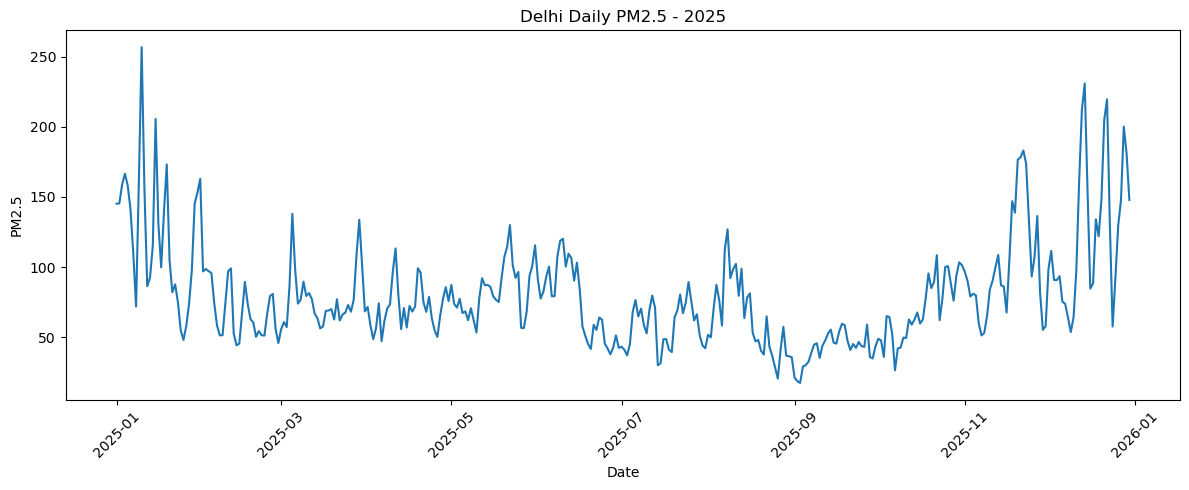

saved


In [95]:
plt.figure(figsize=(12, 5))
plt.plot(model_df["date"], model_df["pm2_5"])
plt.title("Delhi Daily PM2.5 - 2025")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/delhi_daily_pm25_2025.png")
plt.show()

print("saved")

In [97]:
corr_df = model_df.drop(columns=["date", "risk_category_next_day"], errors="ignore").corr()

print(corr_df["target_pm2_5_next_day"].sort_values(ascending=False))

target_pm2_5_next_day    1.000000
pm2_5                    0.813563
sulphur_dioxide          0.673240
nitrogen_dioxide         0.533649
us_aqi                   0.259565
pm10                     0.213074
ozone                   -0.064276
WS10M                   -0.222650
PRECTOTCORR             -0.269798
RH2M                    -0.304670
T2M                     -0.416716
Name: target_pm2_5_next_day, dtype: float64


In [99]:
corr_df.to_csv("outputs/correlation_matrix_2025.csv")
print("saved")

saved


## Project status summary

Data for Delhi air quality and weather for 2025 was successfully collected, cleaned, merged, and transformed into a modeling dataset for next-day PM2.5 forecasting.

The final processed dataset contains daily pollutant and meteorological variables, along with a next-day PM2.5 target and a derived pollution risk category.

Multiple models were tested. The baseline persistence model performed best, outperforming Linear Regression and Random Forest models. This indicates that short-term PM2.5 persistence is a dominant signal in the dataset.

Risk categories were successfully created and summarized, and key visual and correlation outputs were saved for use in the final portfolio project and research paper.

In [102]:
final_summary = pd.DataFrame({
    "Metric": ["Best Model", "Baseline MAE", "Baseline RMSE", "Baseline R2", "Rows in final model data"],
    "Value": ["Baseline Persistence", 15.52478250915751, 22.963507026633046, 0.6284562026479149, len(model_df)]
})

print(final_summary)

                     Metric                 Value
0                Best Model  Baseline Persistence
1              Baseline MAE             15.524783
2             Baseline RMSE             22.963507
3               Baseline R2              0.628456
4  Rows in final model data                   364


In [104]:
final_summary.to_csv("outputs/final_metrics_summary_2025.csv", index=False)
print("saved")

saved


## Abstract

This project develops an end-to-end air-quality forecasting pipeline for Delhi using open-source air-pollution and meteorological data for 2025. Hourly air-quality measurements were collected and aggregated to daily level, then merged with daily weather variables to construct a forecasting dataset for next-day PM2.5 prediction.

The study evaluated multiple forecasting approaches, including a baseline persistence model, Linear Regression, and Random Forest models. Results showed that the baseline persistence model outperformed the tested machine learning models, achieving the lowest error and highest explanatory power. This indicates that short-term PM2.5 persistence is a dominant predictive signal in the current dataset.

In addition to forecasting, the project translated predicted PM2.5 levels into practical pollution-risk categories, creating a simple early-warning framework. The analysis also showed meaningful relationships between next-day PM2.5 and variables such as sulphur dioxide, nitrogen dioxide, temperature, humidity, wind speed, and precipitation.

The project demonstrates a complete applied data-science workflow, from data acquisition and processing to modeling, evaluation, interpretation, and risk communication. It also provides a strong foundation for a statistics research paper on urban air-quality forecasting in Delhi.